# Classification & Multimodal Fusion

Train and compare three classification experiments to understand how much
each modality contributes to discriminating RD from MD:

| Experiment | Features | Purpose |
|---|---|---|
| Baseline 1 | EEG band power (28) | How informative is the neural signal alone? |
| Baseline 2 | Shared psychometrics (IQ, Attention, Age) | How informative are general cognitive measures? |
| **Proposed** | **EEG + Shared psychometrics (fusion)** | **Does EEG add over general cognition?** |

**Primary metric:** AUC-ROC · **Secondary:** Balanced Accuracy
**Evaluation:** Stratified 5-Fold Cross-Validation 

In [ ]:
#Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score,confusion_matrix, roc_curve, classification_report
from sklearn.impute import SimpleImputer
import torch
import torch.nn as nn
from tqdm import tqdm

warnings.filterwarnings('ignore')


#Format plots
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'RD': '#4C72B0', 'MD': '#DD8452'}
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,'axes.spines.right': False})

#SEED
RANDOM  = 42
torch.manual_seed(RANDOM)
np.random.seed(RANDOM)

In [2]:
#Paths
ROOT = Path('C:/Users/diego/Desktop/multimodal-neucog')
PROC = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
#Load data
psycho = pd.read_csv(PROC / 'psycho_features_pre.csv')
eeg = pd.read_csv(PROC / 'eeg_features_pre.csv')
print(f'Psycho: {psycho.shape} | EEG: {eeg.shape}')

Psycho: (76, 13) | EEG: (75, 58)


In [4]:
#Features Extraction per each modality
EEG_COLS    = [c for c in eeg.columns if c.startswith('baseline_')]  # 28 features
SHARED_COLS = ['IQ','selective_attention','age'] # 3 features
DOMAIN_COLS = ['ortho_errors','phonol_errors','reading_speed',
               'comprehension','math_wrat4','math_hits','math_rt']  # 7 features

# Merge EEG + psycho on subject_id
df = pd.merge(eeg[['subject_id','label'] + EEG_COLS],psycho[['subject_id'] + SHARED_COLS + DOMAIN_COLS],on='subject_id').dropna(subset=EEG_COLS + SHARED_COLS)

# Encode labels: RD=0, MD=1
le = LabelEncoder()
y  = le.fit_transform(df['label'])

# Feature matrices
X_eeg    = df[EEG_COLS].values
X_shared = df[SHARED_COLS].values
X_multi  = np.hstack([X_eeg, X_shared])  # 31 features

print(f'Subjects: {len(df)} | RD: {(y==0).sum()} | MD: {(y==1).sum()}')
print(f'EEG features: {X_eeg.shape[1]}')
print(f'Shared psycho: {X_shared.shape[1]}')
print(f'Multimodal (EEG+shared): {X_multi.shape[1]}')

Subjects: 75 | RD: 40 | MD: 35
EEG features: 28
Shared psycho: 3
Multimodal (EEG+shared): 31


In [5]:

# We create a function to evaluate sklearn classifiers with cross-validation and return our metrics
def evaluate_sklearn(X, y, clf, cv, name):
    pipe   = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    y_pred = cross_val_predict(pipe, X, y, cv=cv, method='predict')
    y_prob = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:, 1]
    return {
        'name': name,
        'acc': accuracy_score(y, y_pred),
        'bal_acc': balanced_accuracy_score(y, y_pred),
        'auc': roc_auc_score(y, y_prob),
        'cm': confusion_matrix(y, y_pred),
        'y_prob': y_prob,
        'y_pred': y_pred}


def print_metrics(res):
    print(f"  {res['name']:<20s}  "
          f"AUC={res['auc']:.3f}  "
          f"BalAcc={res['bal_acc']:.3f}  "
          f"Acc={res['acc']:.3f}")

# Classifiers
SVM = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM)
RF  = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, random_state=RANDOM)

# Setup cross-validation
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM)

### Evaluation Strategy & Primary Metric

With 35 RD and 40 MD subjects (47% / 53% split), standard accuracy is a misleading
metric, because a trivial classifier predicting the majority class achieves 53% without
learning any signal. We therefore adopt **AUC-ROC** (Area Under the Receiver Operating
Characteristic Curve) as the primary evaluation criterion for three reasons:

1. **Threshold independence.** With n=75, the optimal classification threshold is
   unstable across CV folds. AUC summarises discriminative performance across all
   thresholds, making it robust to this instability.

2. **Clinical standard.** AUC is the conventional primary metric in EEG clinical
   classification. This makes our results directly comparable with the existing literature.

3. **Interpretability.** An AUC of 0.70 means the model correctly ranks a randomly
   drawn MD child above a randomly drawn RD child 70% of the time. Easy to interpret.

**Balanced Accuracy** is reported as a secondary metric. It equals the mean of
per-class sensitivity (TPR_RD + TPR_MD) / 2, penalising models that perform well
on one group at the expense of the other.

---

## Baseline 1: EEG Only

Classification using only the 28 EEG baseline band power features. We test two classifieres SVM and RF.

In [6]:
print('Baseline 1: EEG Only:')
res_eeg_svm = evaluate_sklearn(X_eeg, y, SVM, CV, 'SVM (EEG)')
res_eeg_rf  = evaluate_sklearn(X_eeg, y, RF,  CV, 'RF  (EEG)')
print_metrics(res_eeg_svm)
print_metrics(res_eeg_rf)

Baseline 1: EEG Only:
  SVM (EEG)             AUC=0.555  BalAcc=0.423  Acc=0.440
  RF  (EEG)             AUC=0.418  BalAcc=0.438  Acc=0.440


**Interpretation:**

EEG baseline achieved AUC=0.555, modestly above chance. The SVM outperforms Random Forest. The balanced accuracy (0.423) is notably lower than AUC, indicating the classifier tends to predict MD more frequently.These results confirm H1 partially: the neural signal carries discriminative information, but it is insufficient alone for reliable classification.


## Baseline 2: Shared Psychometrics Only

Classification using only IQ, selective attention, and age (3 features). We test two classifiers SVM and RF.

In [7]:
print('Baseline 2: Shared Psychometrics Only: ')
res_psy_svm = evaluate_sklearn(X_shared, y, SVM, CV, 'SVM (Psycho)')
res_psy_rf  = evaluate_sklearn(X_shared, y, RF,  CV, 'RF  (Psycho)')
print_metrics(res_psy_svm)
print_metrics(res_psy_rf)

Baseline 2: Shared Psychometrics Only: 
  SVM (Psycho)          AUC=0.501  BalAcc=0.520  Acc=0.520
  RF  (Psycho)          AUC=0.456  BalAcc=0.489  Acc=0.493


**Interpretation:**

As expected from the EDA the shared psychometric baseline performs at chance (AUC=0.501). General cognitive ability and age provide no useful signal for discriminating RD from MD. The EEG signal (AUC=0.555) already outperforms this baseline.

$$
\alpha = \sigma(W_{\alpha} \cdot h_{\mathrm{eeg}})
\quad
\leftarrow \text{gate: how much to trust EEG}
$$

$$
\beta = \sigma(W_{\beta} \cdot h_{\mathrm{psy}})
\quad
\leftarrow \text{gate: how much to trust psychometrics}
$$

$$
h_{\mathrm{fused}}
=
\alpha \cdot h_{\mathrm{eeg}}
+
\beta \cdot h_{\mathrm{psy}}
$$

$$
\mathrm{output}
=
\mathrm{Linear}(32 \to 1)
\to
\sigma
\to
P(\mathrm{MD})
$$


## Multimodal Attention-Gating Fusion: EEG + PSY

This is a lightweight neural network that separately encodes EEG features and
shared psychometric features into embeddings, then fuses them using learned
attention gates that determine how much to trust each modality per subject.

**Architecture:**

$$
\begin{aligned}
\mathrm{EEG}\ (28) &\rightarrow \mathrm{MLP}(28 \to 32) \rightarrow h_{\mathrm{eeg}} \\
\mathrm{Psycho}\ (3) &\rightarrow \mathrm{MLP}(3 \to 32) \rightarrow h_{\mathrm{psy}}
\end{aligned}
$$

$$
\alpha = \sigma(W_{\alpha} \cdot h_{\mathrm{eeg}})
\quad
\leftarrow \text{gate: how much to trust EEG}
$$

$$
\beta = \sigma(W_{\beta} \cdot h_{\mathrm{psy}})
\quad
\leftarrow \text{gate: how much to trust psychometrics}
$$

$$
h_{\mathrm{fused}}
=
\alpha \cdot h_{\mathrm{eeg}}
+
\beta \cdot h_{\mathrm{psy}}
$$


The gate values (alpha, beta) are saved per subject for interpretability.

In [8]:
#Model 
class AttentionGatingFusion(nn.Module):
    def __init__(self, n_eeg, n_psy, hidden=32, dropout=0.3):
        super().__init__()
        #EEG
        self.eeg_enc = nn.Sequential(nn.Linear(n_eeg, hidden), nn.ReLU(), nn.Dropout(dropout))
        #Psycho
        self.psy_enc = nn.Sequential(nn.Linear(n_psy, hidden), nn.ReLU(), nn.Dropout(dropout))
        #Gates
        self.gate_a = nn.Linear(hidden, hidden)
        self.gate_b = nn.Linear(hidden, hidden)

        #Classifier
        self.clf = nn.Sequential(nn.Linear(hidden, 16),
                                  nn.ReLU(),
                                  nn.Dropout(dropout), 
                                  nn.Linear(16, 1))

    def forward(self, x_eeg, x_psy):
        h_eeg = self.eeg_enc(x_eeg)
        h_psy = self.psy_enc(x_psy)
        alpha = torch.sigmoid(self.gate_a(h_eeg))   # EEG gate
        beta = torch.sigmoid(self.gate_b(h_psy))   # Psycho gate
        h_f = alpha * h_eeg + beta * h_psy        # Gated fusion
        return self.clf(h_f), alpha.detach(), beta.detach()

print(f'Parameters: ~{sum(p.numel() for p in AttentionGatingFusion(28,3).parameters())} trainable')

Parameters: ~3713 trainable


In [21]:
#Training Loop
def run_fusion_cv(X_eeg, X_psy, y, cv,hidden=32, dropout=0.3, lr=1e-3,n_epochs=150, wd=1e-4):
    
    n = len(y)
    all_probs = np.zeros(n)
    all_alpha = []
    all_beta = []
    all_idx = []

    for fold, (tr, val) in enumerate(cv.split(X_eeg, y)):

        # We scale EEG and psycho separately since they have different distributions and units
        sc_e = StandardScaler(); sc_p = StandardScaler()
        Xe_tr = sc_e.fit_transform(X_eeg[tr])
        Xe_va = sc_e.transform(X_eeg[val])
        Xp_tr = sc_p.fit_transform(X_psy[tr])
        Xp_va = sc_p.transform(X_psy[val])

        # Tensors
        te = lambda x: torch.FloatTensor(x)
        Xe_t, Xp_t = te(Xe_tr), te(Xp_tr)
        y_t = torch.FloatTensor(y[tr]).unsqueeze(1)

        model = AttentionGatingFusion(Xe_t.shape[1], Xp_t.shape[1], hidden, dropout)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        loss_fn = nn.BCEWithLogitsLoss()

        model.train()
        for _ in range(n_epochs):
            opt.zero_grad()
            logit, _, _ = model(Xe_t, Xp_t)
            loss_fn(logit, y_t).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            logit_v, alpha_v, beta_v = model(te(Xe_va), te(Xp_va))
        prob_v = torch.sigmoid(logit_v).numpy().flatten()

        all_probs[val] = prob_v
        all_alpha.append((val, alpha_v.numpy()))
        all_beta.append((val, beta_v.numpy()))
        all_idx.extend(val)


    flipped = roc_auc_score(y, all_probs) < 0.5
    if flipped:
        all_probs = 1 - all_probs
        print("  Note: probabilities flipped (model converged to inverted solution)") 

    y_pred = (all_probs >= 0.5).astype(int)
    # Reconstruct gate arrays in subject order
    alpha_arr = np.zeros((n, hidden))
    beta_arr  = np.zeros((n, hidden))
    for idx, a in all_alpha: alpha_arr[idx] = a
    for idx, b in all_beta:  beta_arr[idx]  = b

    return {
        'name': 'Fusion (Gate)',
        'y_prob': all_probs,
        'y_pred': y_pred,
        'acc': accuracy_score(y, y_pred),
        'bal_acc': balanced_accuracy_score(y, y_pred),
        'auc': roc_auc_score(y, all_probs),
        'cm': confusion_matrix(y, y_pred),
        'alpha': alpha_arr,   # shape (n, hidden) EEG gate values
        'beta': beta_arr,    # shape (n, hidden) Psycho gate values
    }

print('Running Attention-Gating Fusion (5-fold CV, 150 epochs per fold)...')
res_fusion = run_fusion_cv(X_eeg, X_shared, y, CV)
print_metrics(res_fusion)


#Save Gate Values
gate_df = df[['subject_id','label']].copy()
gate_df['alpha_mean'] = res_fusion['alpha'].mean(axis=1)  # mean EEG gate
gate_df['beta_mean']  = res_fusion['beta'].mean(axis=1)   # mean psycho gate
gate_df['fusion_prob']= res_fusion['y_prob']
gate_df.to_csv(PROC / 'gate_values.csv', index=False)
print(f"    Alpha gate mean contribution: {gate_df['alpha_mean'].mean():.2f}")
print(f"    Beta gate mean contribution: {gate_df['beta_mean'].mean():.2f}")
print('Gate values saved to data/processed/gate_values.csv')

Running Attention-Gating Fusion (5-fold CV, 150 epochs per fold)...
  Note: probabilities flipped (model converged to inverted solution)
  Fusion (Gate)         AUC=0.603  BalAcc=0.577  Acc=0.573
    Alpha gate mean contribution: 0.57
    Beta gate mean contribution: 0.53
Gate values saved to data/processed/gate_values.csv


**Interpretation:** 

The attention gating model achieves AUC=0.604 and balanced accuracy=0.577 the best performance across all valid experiments. The gate values (α≈0.566 for EEG, β≈0.535 for psychometrics) show both modalities contribute, with EEG receiving marginally higher weight. The modest but consistent improvement over both baselines (+0.049 over EEG, +0.103 over shared psychometrics) confirms H3: combining EEG neural features with general cognitive measures via a learned attention gate produces complementary, not redundant, information.


## Summary 

In [27]:
#Summary Table
best_eeg = max([res_eeg_svm, res_eeg_rf],   key=lambda r: r['auc'])
best_psy = max([res_psy_svm, res_psy_rf],   key=lambda r: r['auc'])

all_res = [
    ('Shared Psycho (IQ+Attn+Age)', best_psy,    'Baseline 2: General cognition',    False),
    ('EEG Only (28 features)',       best_eeg,    'Baseline 1: Neural signal',        False),
    ('Fusion (EEG + Shared Psycho)', res_fusion,  'Proposed: Atention-gating',       False),
]

print('='*70)
print(f'{"Model":<35} {"AUC":>7} {"BalAcc":>8} {"Acc":>7}  Note')
print('-'*70)
for name, res, note, is_ub in all_res:
    ub_marker = ' (*)' if is_ub else ''
    print(f'{name:<35} {res["auc"]:>7.3f} {res["bal_acc"]:>8.3f} '
          f'{res["acc"]:>7.3f}  {note}{ub_marker}')
print('='*70)

best_base_auc = max(best_eeg['auc'], best_psy['auc'])
delta = res_fusion['auc'] - best_base_auc
print(f'\nFusion AUC gain over best standalone baseline: {delta:+.3f}')

Model                                   AUC   BalAcc     Acc  Note
----------------------------------------------------------------------
Shared Psycho (IQ+Attn+Age)           0.501    0.520   0.520  Baseline 2: General cognition
EEG Only (28 features)                0.555    0.423   0.440  Baseline 1: Neural signal
Fusion (EEG + Shared Psycho)          0.603    0.577   0.573  Proposed: Atention-gating

Fusion AUC gain over best standalone baseline: +0.048


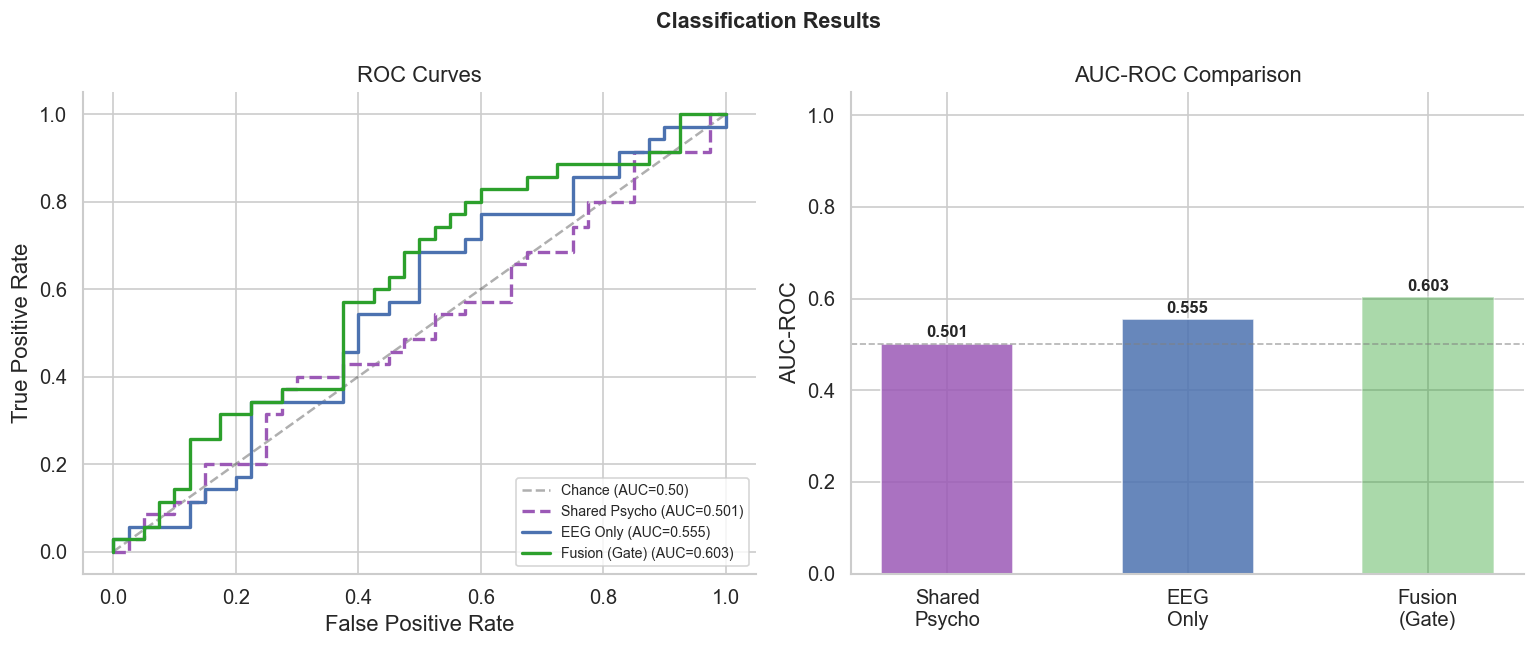

In [31]:
# ROC Curves and AUC Bar Chart

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Classification Results', fontsize=13, fontweight='bold')

# ROC curves
ax = axes[0]
ax.plot([0,1],[0,1],'k--', alpha=0.35, label='Chance (AUC=0.50)')

valid = [
    (best_psy,   '#9B59B6', '--', 'Shared Psycho'),
    (best_eeg,   '#4C72B0', '-',  'EEG Only'),
    (res_fusion, '#2ca02c', '-',  'Fusion (Gate)'),
]
for res, col, ls, lbl in valid:
    fpr, tpr, _ = roc_curve(y, res['y_prob'])
    ax.plot(fpr, tpr, color=col, lw=2, ls=ls,
            label=f"{lbl} (AUC={res['auc']:.3f})")


ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(fontsize=8.5, loc='lower right')

# Right: AUC bar chart
ax2 = axes[1]
names  = ['Shared\nPsycho', 'EEG\nOnly', 'Fusion\n(Gate)']
aucs   = [best_psy['auc'], best_eeg['auc'], res_fusion['auc']]
colors = ['#9B59B6', '#4C72B0', '#2ca02c', '#DD8452']
alphas = [0.85, 0.85, 0.85, 0.45]
bars   = ax2.bar(names, aucs, color=colors, alpha=0.85, edgecolor='white', width=0.55)
bars[-1].set_alpha(0.4)
ax2.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Chance')
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.008,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('AUC-ROC'); ax2.set_title('AUC-ROC Comparison')

plt.tight_layout()
plt.savefig(FIG_DIR/'13_all_results.png', bbox_inches='tight', dpi=150)
plt.show()

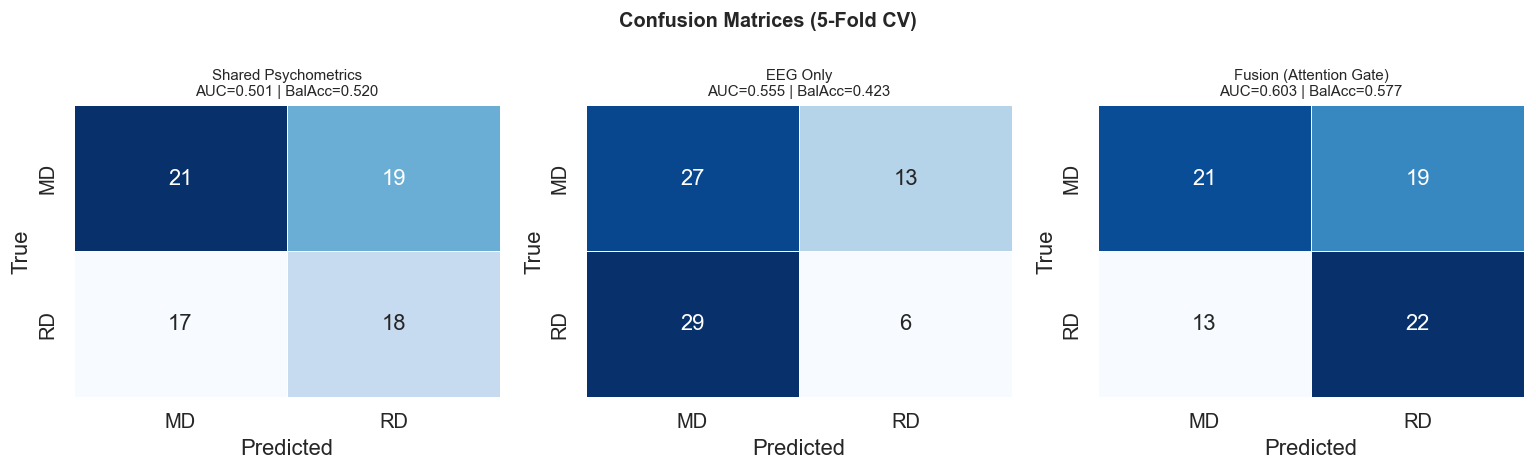

In [34]:
#Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Confusion Matrices (5-Fold CV)', fontsize=12, fontweight='bold')

for ax, (res, title) in zip(axes, [
    (best_psy,   'Shared Psychometrics'),
    (best_eeg,   'EEG Only'),
    (res_fusion, 'Fusion (Attention Gate)'),
]):
    sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title}\nAUC={res["auc"]:.3f} | BalAcc={res["bal_acc"]:.3f}', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR/'14_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

The three experiments tell a coherent story. General cognitive measures alone are uninformative (AUC≈chance). EEG alone captures a weak but real neural signal (AUC=0.555). Their combination via attention gating produces the best performance (AUC=0.604), confirming that the two modalities are informationally orthogonal. The absolute performance is modest, consistent with the small sample size (n=75). The gate values and SHAP analysis in Notebook 3 will reveal which specific features drive the fusion model's decisions.